# **Seoul Bike Sharing Demand Prediction Project**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/content/drive/MyDrive/Data Sets/SeoulBikeData.csv",encoding = "ISO-8859-1")
df.shape

(8760, 14)

In [3]:
df.head()

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


In [4]:
df.tail()

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
8755,30/11/2018,1003,19,4.2,34,2.6,1894,-10.3,0.0,0.0,0.0,Autumn,No Holiday,Yes
8756,30/11/2018,764,20,3.4,37,2.3,2000,-9.9,0.0,0.0,0.0,Autumn,No Holiday,Yes
8757,30/11/2018,694,21,2.6,39,0.3,1968,-9.9,0.0,0.0,0.0,Autumn,No Holiday,Yes
8758,30/11/2018,712,22,2.1,41,1.0,1859,-9.8,0.0,0.0,0.0,Autumn,No Holiday,Yes
8759,30/11/2018,584,23,1.9,43,1.3,1909,-9.3,0.0,0.0,0.0,Autumn,No Holiday,Yes


## Data Information

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Date                       8760 non-null   object 
 1   Rented Bike Count          8760 non-null   int64  
 2   Hour                       8760 non-null   int64  
 3   Temperature(°C)            8760 non-null   float64
 4   Humidity(%)                8760 non-null   int64  
 5   Wind speed (m/s)           8760 non-null   float64
 6   Visibility (10m)           8760 non-null   int64  
 7   Dew point temperature(°C)  8760 non-null   float64
 8   Solar Radiation (MJ/m2)    8760 non-null   float64
 9   Rainfall(mm)               8760 non-null   float64
 10  Snowfall (cm)              8760 non-null   float64
 11  Seasons                    8760 non-null   object 
 12  Holiday                    8760 non-null   object 
 13  Functioning Day            8760 non-null   objec

In [6]:
df.describe(include="all").transpose()

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Date,8760,365,01/12/2017,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Rented Bike Count,8760.0,NaN,NaN,NaN,704.602055,644.997468,0.0,191.0,504.5,1065.25,3556.0
Hour,8760.0,NaN,NaN,NaN,11.5,6.922582,0.0,5.75,11.5,17.25,23.0
Temperature(°C),8760.0,NaN,NaN,NaN,12.882922,11.944825,-17.8,3.5,13.7,22.5,39.4
Humidity(%),8760.0,NaN,NaN,NaN,58.226256,20.362413,0.0,42.0,57.0,74.0,98.0
Wind speed (m/s),8760.0,NaN,NaN,NaN,1.724909,1.0363,0.0,0.9,1.5,2.3,7.4
Visibility (10m),8760.0,NaN,NaN,NaN,1436.825799,608.298712,27.0,940.0,1698.0,2000.0,2000.0
Dew point temperature(°C),8760.0,NaN,NaN,NaN,4.073813,13.060369,-30.6,-4.7,5.1,14.8,27.2
Solar Radiation (MJ/m2),8760.0,NaN,NaN,NaN,0.569111,0.868746,0.0,0.0,0.01,0.93,3.52
Rainfall(mm),8760.0,NaN,NaN,NaN,0.148687,1.128193,0.0,0.0,0.0,0.0,35.0


## Check null value

In [7]:
df.isnull().sum()

Date                         0
Rented Bike Count            0
Hour                         0
Temperature(°C)              0
Humidity(%)                  0
Wind speed (m/s)             0
Visibility (10m)             0
Dew point temperature(°C)    0
Solar Radiation (MJ/m2)      0
Rainfall(mm)                 0
Snowfall (cm)                0
Seasons                      0
Holiday                      0
Functioning Day              0
dtype: int64

In [8]:
# Checking duplicate
df.duplicated().sum()

0

In [9]:
# converting date column dtype object to date
df['Date']=pd.to_datetime(df['Date'])

<ipython-input-9-428739332f2e>:2: UserWarning: Parsing dates in DD/MM/YYYY format when dayfirst=False (the default) was specified. This may lead to inconsistently parsed dates! Specify a format to ensure consistent parsing.
  df['Date']=pd.to_datetime(df['Date'])


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Date                       8760 non-null   datetime64[ns]
 1   Rented Bike Count          8760 non-null   int64         
 2   Hour                       8760 non-null   int64         
 3   Temperature(°C)            8760 non-null   float64       
 4   Humidity(%)                8760 non-null   int64         
 5   Wind speed (m/s)           8760 non-null   float64       
 6   Visibility (10m)           8760 non-null   int64         
 7   Dew point temperature(°C)  8760 non-null   float64       
 8   Solar Radiation (MJ/m2)    8760 non-null   float64       
 9   Rainfall(mm)               8760 non-null   float64       
 10  Snowfall (cm)              8760 non-null   float64       
 11  Seasons                    8760 non-null   object        
 12  Holida

In [11]:
# define numerical & categorical columns
numeric_features = [feature for feature in df.columns if df[feature].dtype != 'O']
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'O']

# print columns
print('We have {} numerical features : {}'.format(len(numeric_features), numeric_features))
print('\nWe have {} categorical features : {}'.format(len(categorical_features), categorical_features))

We have 11 numerical features : ['Date', 'Rented Bike Count', 'Hour', 'Temperature(°C)', 'Humidity(%)', 'Wind speed (m/s)', 'Visibility (10m)', 'Dew point temperature(°C)', 'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)']

We have 3 categorical features : ['Seasons', 'Holiday', 'Functioning Day']


In [ ]:
# split day of week, month and year in three column
df['weekday'] = df['Date'].dt.day_name()
df['Day'] = df['Date'].dt.day
df["Month"] = df['Date'].dt.month
df["Year"] = df['Date'].dt.year


# drop the Date column
df.drop(columns=['Date'],inplace=True)

In [ ]:
df.head()

,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,weekday,Day,Month,Year
0,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,Thursday,12,1,2017
1,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,Thursday,12,1,2017
2,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes,Thursday,12,1,2017
3,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,Thursday,12,1,2017
4,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes,Thursday,12,1,2017


## **Exploratory data analysis**
### When we observe the data we realize that Hour column is a numerical column but it is a time stamp so we have to treat Hour as a categorical feature

In [ ]:
sns.pairplot(df)

Output hidden; open in https://colab.research.google.com to view.

<ipython-input-22-774cfa2805e4>:2: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  Month=df.groupby("Month").sum().reset_index()


<Axes: xlabel='Month', ylabel='Rented Bike Count'>

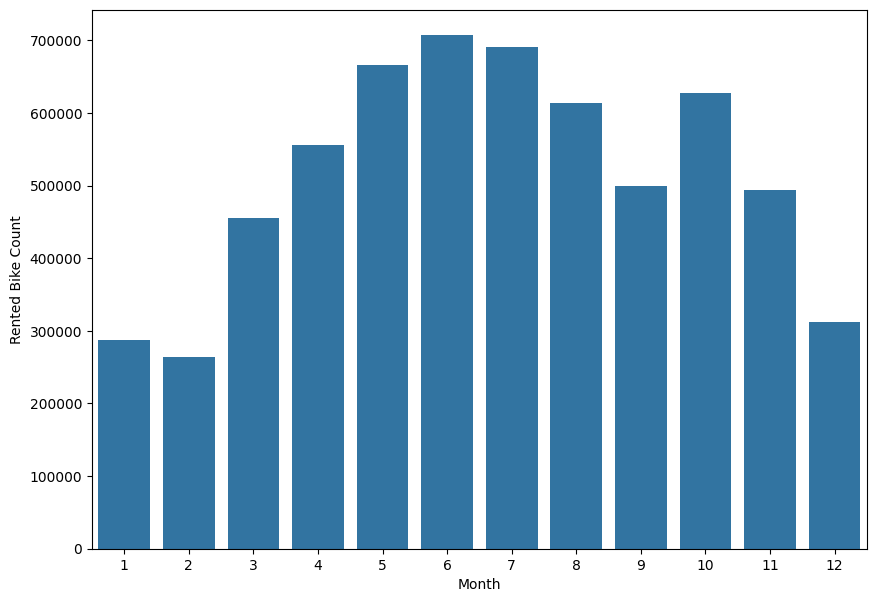

In [ ]:
plt.figure(figsize=(10,7))
Month=df.groupby("Month").sum().reset_index()
sns.barplot(x="Month",y="Rented Bike Count", data=Month)

<ipython-input-23-b4aa735d1609>:2: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  Day=df.groupby("Day").sum().reset_index()


<Axes: xlabel='Day', ylabel='Rented Bike Count'>

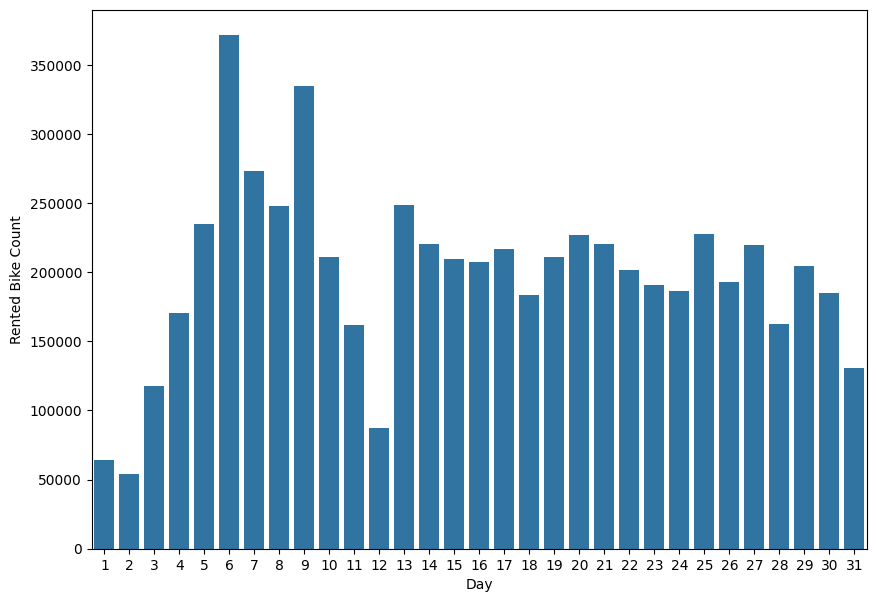

In [ ]:
plt.figure(figsize=(10,7))
Day=df.groupby("Day").sum().reset_index()
sns.barplot(x="Day",y="Rented Bike Count", data=Day)

<ipython-input-24-c7d1b41289bb>:2: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  Hour=df.groupby("Hour").sum().reset_index()


<Axes: xlabel='Hour', ylabel='Rented Bike Count'>

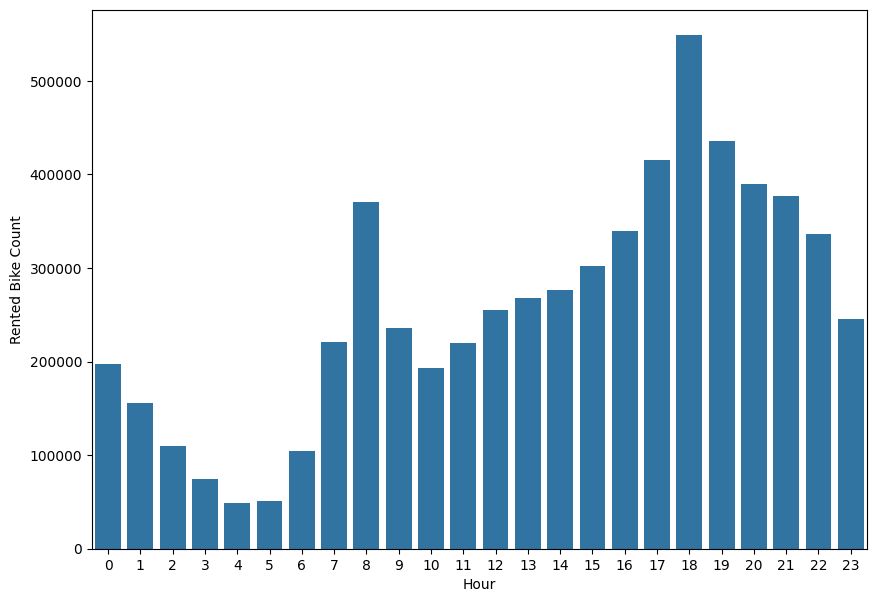

In [ ]:
plt.figure(figsize=(10,7))
Hour=df.groupby("Hour").sum().reset_index()
sns.barplot(x="Hour",y="Rented Bike Count", data=Hour)

<Axes: xlabel='Holiday', ylabel='Rented Bike Count'>

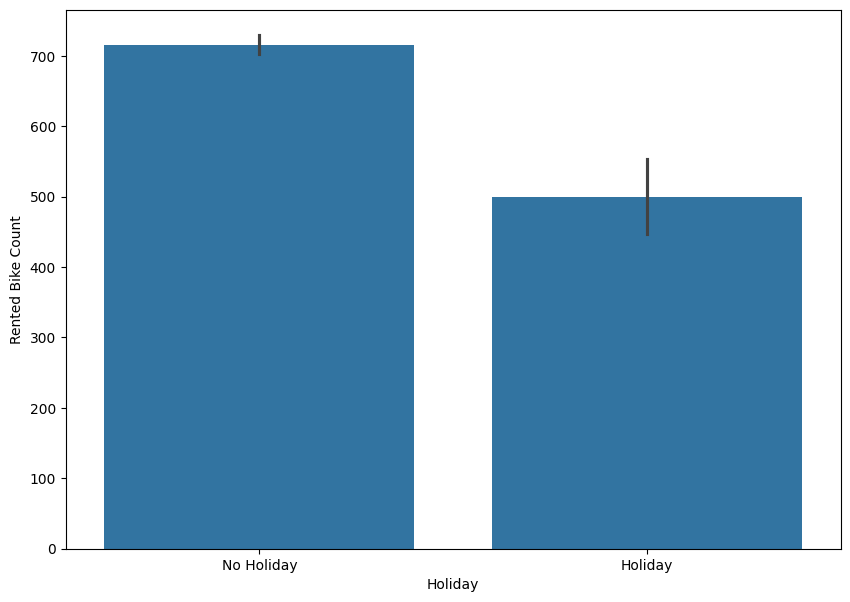

In [ ]:
plt.figure(figsize=(10,7))
sns.barplot(x="Holiday",y="Rented Bike Count", data=df)

<Axes: xlabel='Seasons', ylabel='Rented Bike Count'>

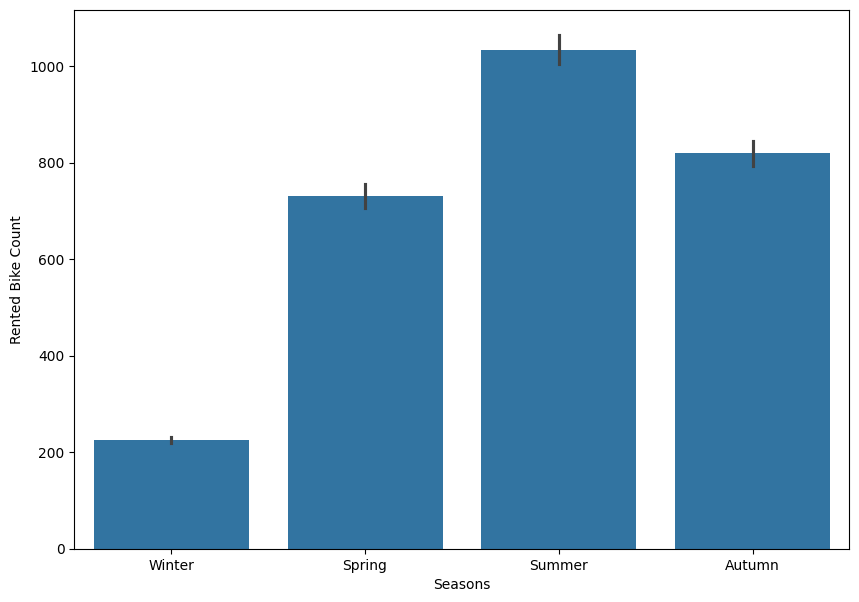

In [ ]:
plt.figure(figsize=(10,7))
sns.barplot(x="Seasons",y="Rented Bike Count", data=df)

<Axes: xlabel='Rainfall(mm)', ylabel='Rented Bike Count'>

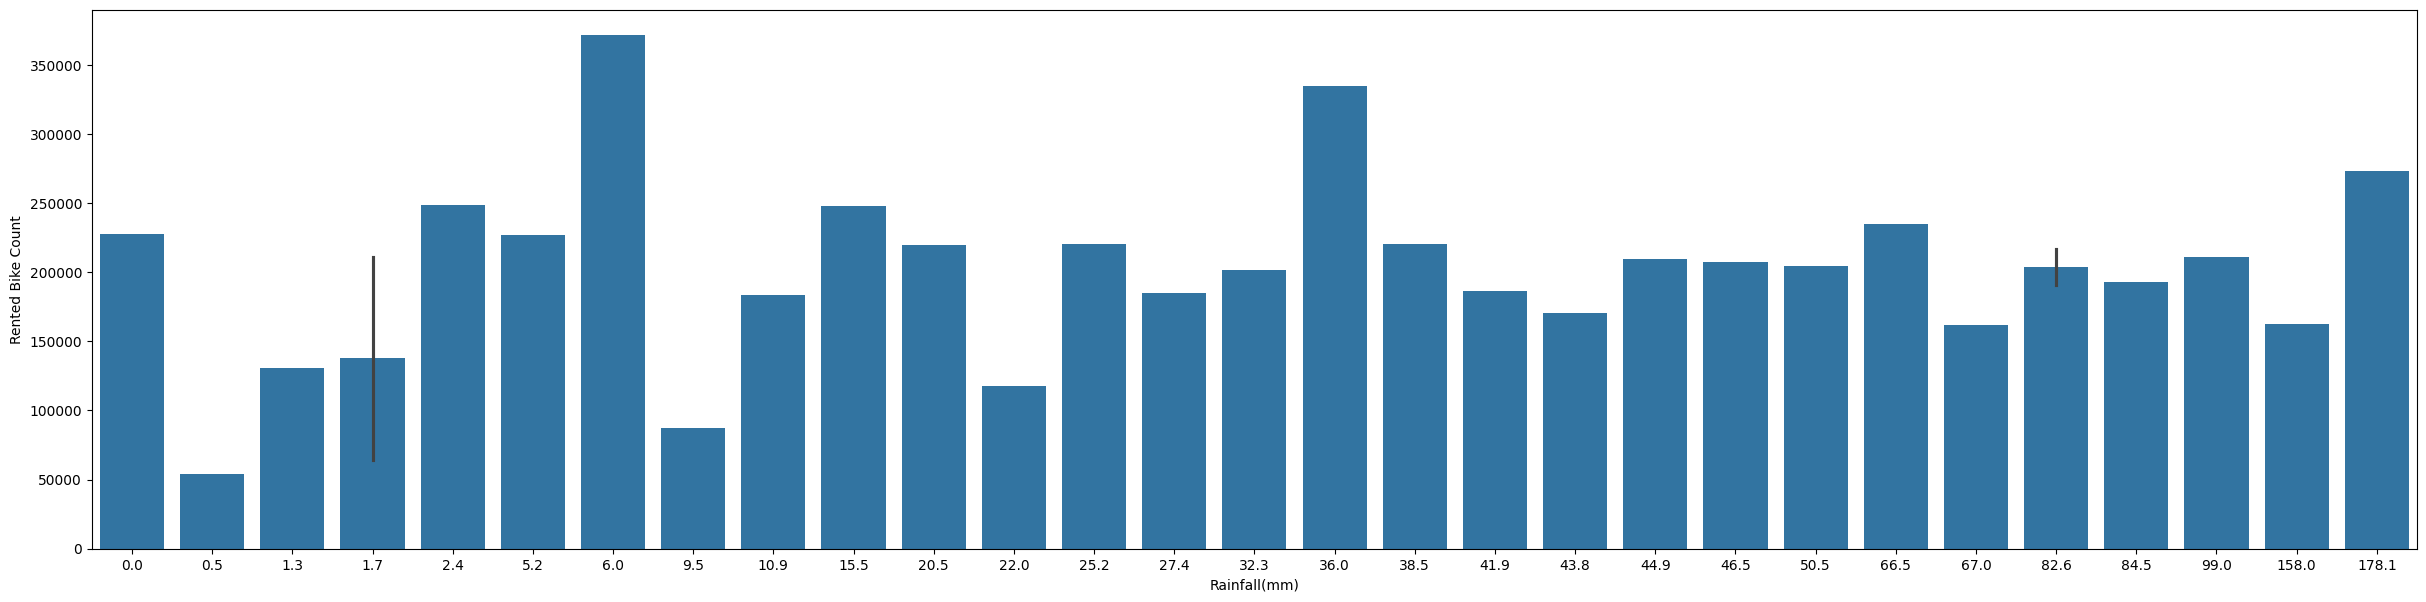

In [ ]:
plt.figure(figsize=(30,7))
sns.barplot(x="Rainfall(mm)",y="Rented Bike Count", data=Day)

<Axes: xlabel='Snowfall (cm)', ylabel='Rented Bike Count'>

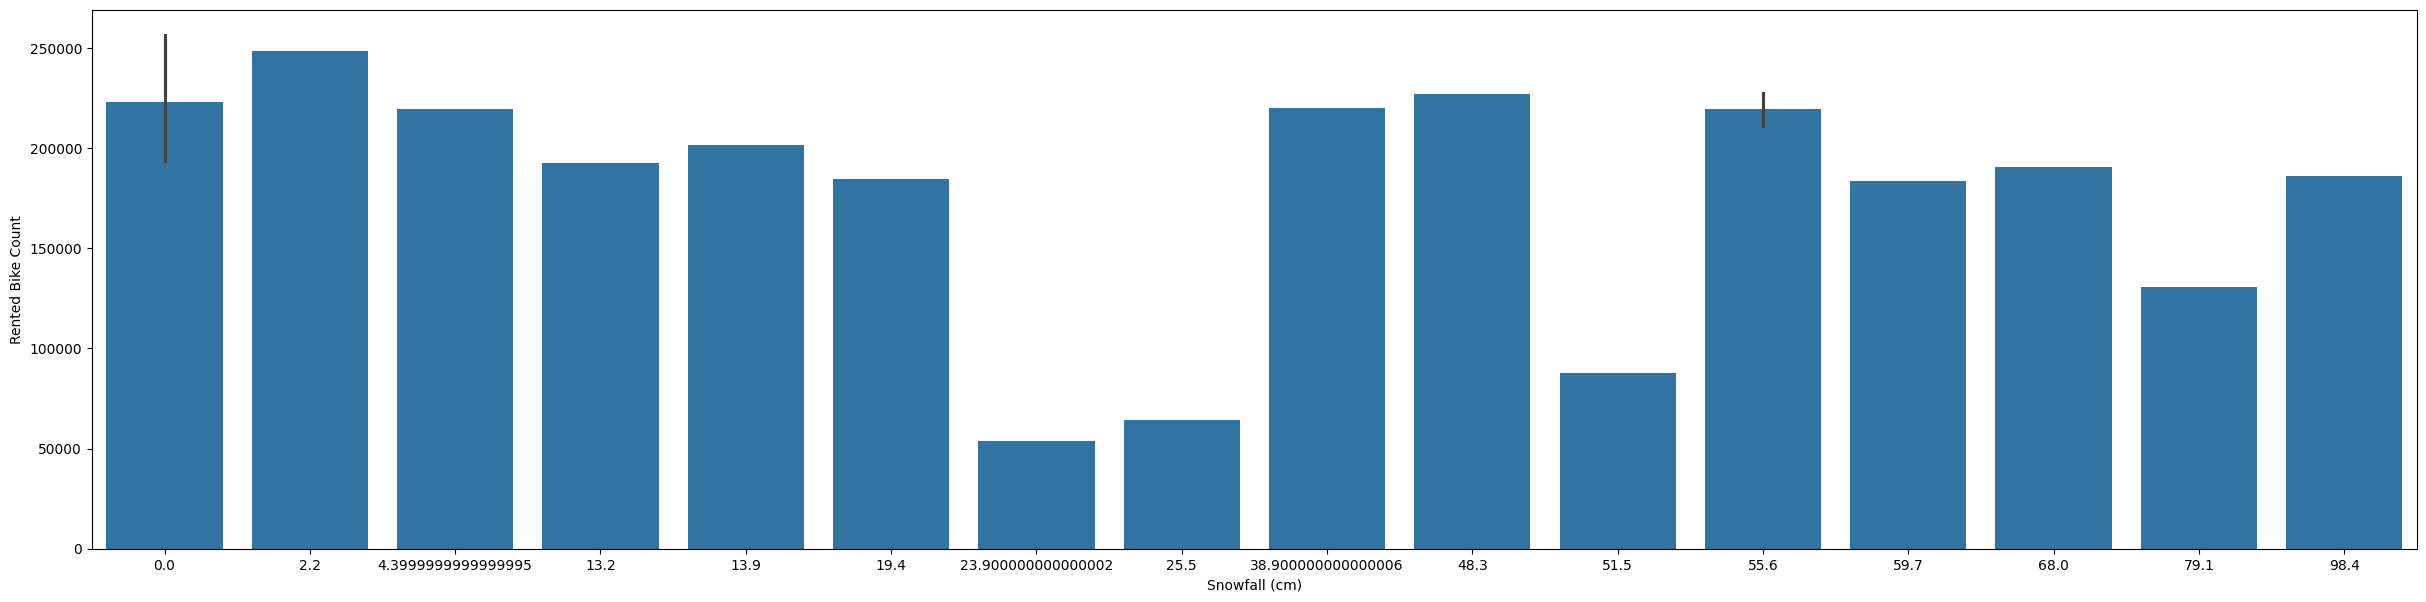

In [ ]:
plt.figure(figsize=(30,7))
sns.barplot(x="Snowfall (cm)",y="Rented Bike Count", data=Day)

<ipython-input-34-571a95cbf9de>:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["Rented Bike Count"])


<Axes: xlabel='Rented Bike Count', ylabel='Density'>

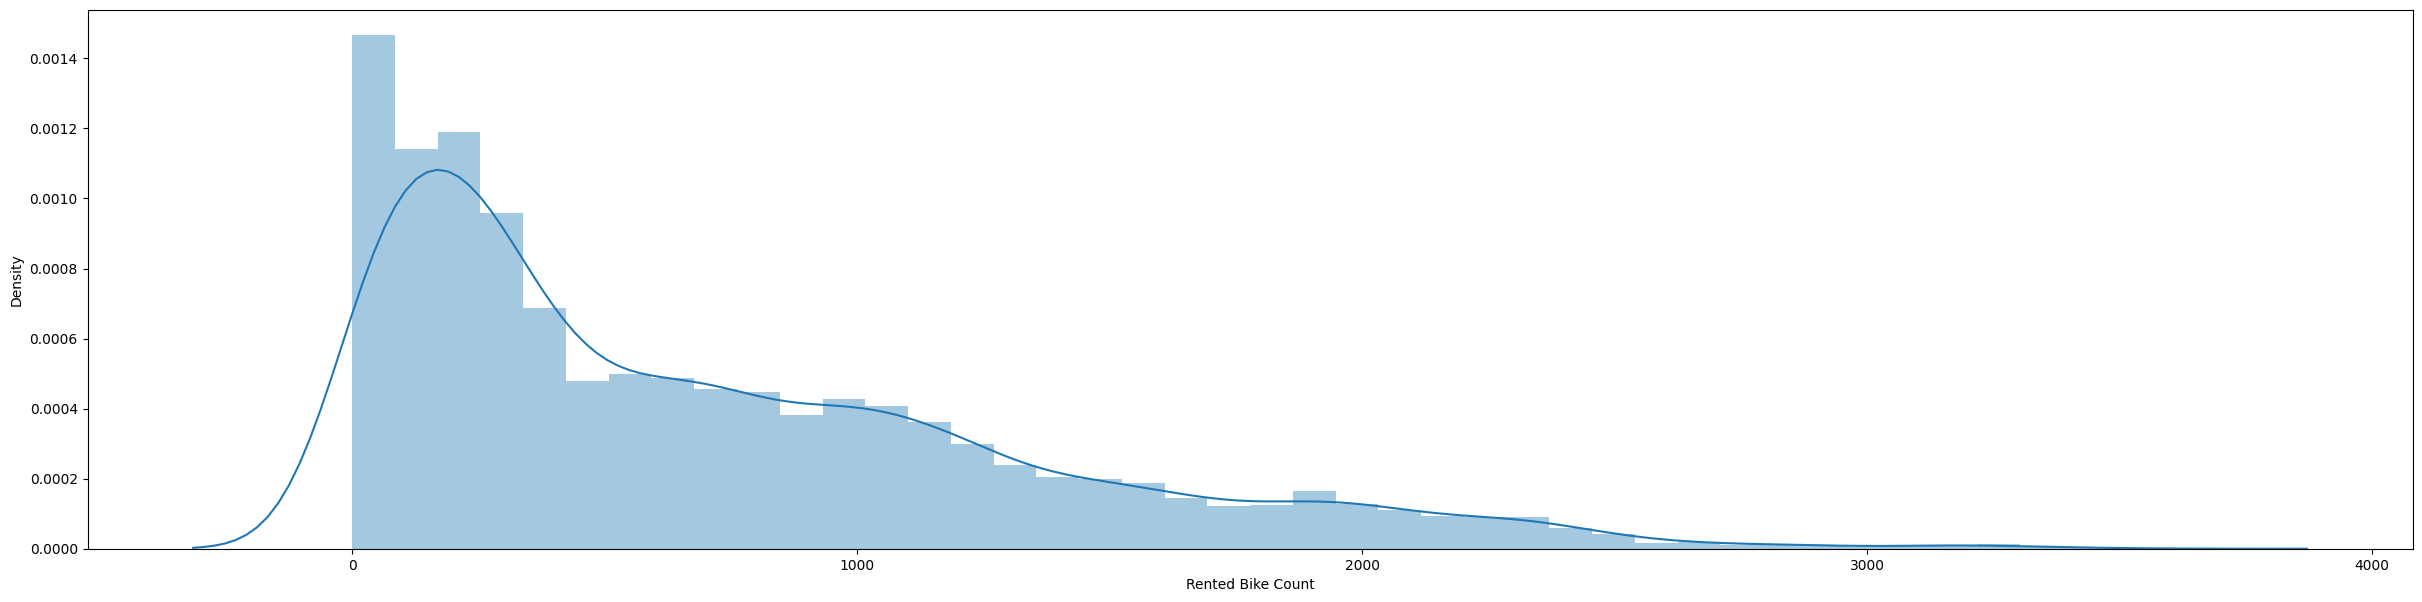

In [ ]:
plt.figure(figsize=(30,7))
sns.distplot(df["Rented Bike Count"])

<ipython-input-35-cf191179ba5c>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(np.sqrt(df["Rented Bike Count"]))


<Axes: xlabel='Rented Bike Count', ylabel='Density'>

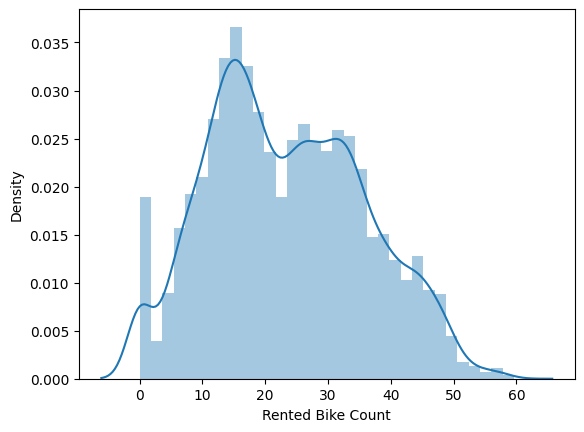

In [ ]:
sns.distplot(np.sqrt(df["Rented Bike Count"]))

## Skewed Data

In [ ]:
df.skew().sort_values(ascending= True)

<ipython-input-13-f720209dc174>:1: FutureWarning: The default value of numeric_only in DataFrame.skew is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  df.skew().sort_values(ascending= True)


Year                         -2.978262
Visibility (10m)             -0.701786
Dew point temperature(°C)    -0.367298
Temperature(°C)              -0.198326
Month                        -0.010458
Hour                          0.000000
Day                           0.007522
Humidity(%)                   0.059579
Wind speed (m/s)              0.890955
Rented Bike Count             1.153428
Solar Radiation (MJ/m2)       1.504040
Snowfall (cm)                 8.440801
Rainfall(mm)                 14.533232
dtype: float64

## Remove Multicollinearity

<ipython-input-18-025cb38456e1>:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(df.corr(),annot=True, cmap="coolwarm")


<Axes: >

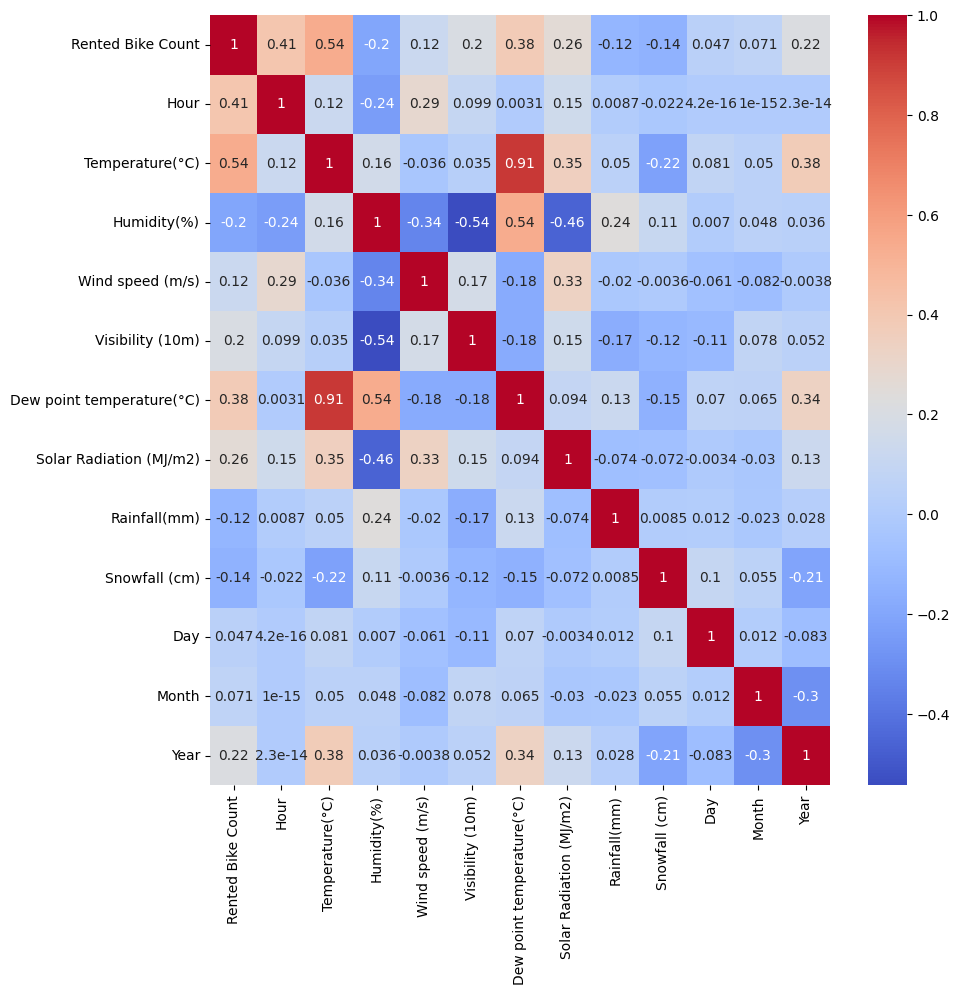

In [ ]:
plt.figure(figsize=(10,10))
sns.heatmap(df.corr(),annot=True, cmap="coolwarm")

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [ ]:
def get_vif(df):
  vif = pd.DataFrame()
  vif["variables"] = df.columns
  vif["VIF"] = [ variance_inflation_factor(df.values, i) for i in range(df.shape[1])]
  return vif

In [ ]:
not_for_vif = ["Day", "Month", "Year", "Rented Bike Count"]

get_vif(df[[i for i in df.describe().columns if i not in not_for_vif]])

,variables,VIF
0,Hour,4.418242
1,Temperature(°C),33.385256
2,Humidity(%),5.371996
3,Wind speed (m/s),4.805364
4,Visibility (10m),9.085977
5,Dew point temperature(°C),17.126199
6,Solar Radiation (MJ/m2),2.881590
7,Rainfall(mm),1.081567
8,Snowfall (cm),1.120833


In [ ]:
not_for_vif = ["Day", "Month", "Year", "Rented Bike Count", "Dew point temperature(°C)"]

get_vif(df[[i for i in df.describe().columns if i not in not_for_vif]])

,variables,VIF
0,Hour,3.921832
1,Temperature(°C),3.228318
2,Humidity(%),4.868221
3,Wind speed (m/s),4.608625
4,Visibility (10m),4.710170
5,Solar Radiation (MJ/m2),2.246791
6,Rainfall(mm),1.079158
7,Snowfall (cm),1.120579


In [ ]:
df.drop(["Dew point temperature(°C)"],axis=1, inplace=True)

## Encoding

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Rented Bike Count        8760 non-null   int64  
 1   Hour                     8760 non-null   int64  
 2   Temperature(°C)          8760 non-null   float64
 3   Humidity(%)              8760 non-null   int64  
 4   Wind speed (m/s)         8760 non-null   float64
 5   Visibility (10m)         8760 non-null   int64  
 6   Solar Radiation (MJ/m2)  8760 non-null   float64
 7   Rainfall(mm)             8760 non-null   float64
 8   Snowfall (cm)            8760 non-null   float64
 9   Seasons                  8760 non-null   object 
 10  Holiday                  8760 non-null   object 
 11  Functioning Day          8760 non-null   object 
 12  weekday                  8760 non-null   object 
 13  Day                      8760 non-null   int64  
 14  Month                   

In [ ]:
cat_features = ["Seasons","Holiday","Functioning Day","weekday"]

In [ ]:
df["Holiday"].value_counts()

No Holiday    8328
Holiday        432
Name: Holiday, dtype: int64

In [ ]:
df["Functioning Day"].value_counts()

Yes    8465
No      295
Name: Functioning Day, dtype: int64

In [ ]:
df["Seasons"].value_counts()

Spring    2208
Summer    2208
Autumn    2184
Winter    2160
Name: Seasons, dtype: int64

In [ ]:
df["weekday"].value_counts()

Sunday       1296
Wednesday    1272
Tuesday      1272
Thursday     1248
Saturday     1248
Friday       1224
Monday       1200
Name: weekday, dtype: int64

In [ ]:
df["Holiday"] = df["Holiday"].map({"No Holiday":0, "Holiday":1})
df["Functioning Day"] = df["Functioning Day"].map({"No":0, "Yes":1})

In [ ]:
df_season = pd.get_dummies(df["Seasons"], drop_first= True)
df_weekday = pd.get_dummies(df["weekday"], drop_first= True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Rented Bike Count        8760 non-null   int64  
 1   Hour                     8760 non-null   int64  
 2   Temperature(°C)          8760 non-null   float64
 3   Humidity(%)              8760 non-null   int64  
 4   Wind speed (m/s)         8760 non-null   float64
 5   Visibility (10m)         8760 non-null   int64  
 6   Solar Radiation (MJ/m2)  8760 non-null   float64
 7   Rainfall(mm)             8760 non-null   float64
 8   Snowfall (cm)            8760 non-null   float64
 9   Seasons                  8760 non-null   object 
 10  Holiday                  8760 non-null   int64  
 11  Functioning Day          8760 non-null   int64  
 12  weekday                  8760 non-null   object 
 13  Day                      8760 non-null   int64  
 14  Month                   

In [ ]:
df = pd.concat([df, df_season, df_weekday], axis=1)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Rented Bike Count        8760 non-null   int64  
 1   Hour                     8760 non-null   int64  
 2   Temperature(°C)          8760 non-null   float64
 3   Humidity(%)              8760 non-null   int64  
 4   Wind speed (m/s)         8760 non-null   float64
 5   Visibility (10m)         8760 non-null   int64  
 6   Solar Radiation (MJ/m2)  8760 non-null   float64
 7   Rainfall(mm)             8760 non-null   float64
 8   Snowfall (cm)            8760 non-null   float64
 9   Seasons                  8760 non-null   object 
 10  Holiday                  8760 non-null   int64  
 11  Functioning Day          8760 non-null   int64  
 12  weekday                  8760 non-null   object 
 13  Day                      8760 non-null   int64  
 14  Month                   

In [ ]:
df.drop(["Seasons","weekday"], axis=1, inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Rented Bike Count        8760 non-null   int64  
 1   Hour                     8760 non-null   int64  
 2   Temperature(°C)          8760 non-null   float64
 3   Humidity(%)              8760 non-null   int64  
 4   Wind speed (m/s)         8760 non-null   float64
 5   Visibility (10m)         8760 non-null   int64  
 6   Solar Radiation (MJ/m2)  8760 non-null   float64
 7   Rainfall(mm)             8760 non-null   float64
 8   Snowfall (cm)            8760 non-null   float64
 9   Holiday                  8760 non-null   int64  
 10  Functioning Day          8760 non-null   int64  
 11  Day                      8760 non-null   int64  
 12  Month                    8760 non-null   int64  
 13  Year                     8760 non-null   int64  
 14  Spring                  

In [ ]:
df.head()

,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Holiday,...,Year,Spring,Summer,Winter,Monday,Saturday,Sunday,Thursday,Tuesday,Wednesday
0,254,0,-5.2,37,2.2,2000,0.0,0.0,0.0,0,...,2017,0,0,1,0,0,0,1,0,0
1,204,1,-5.5,38,0.8,2000,0.0,0.0,0.0,0,...,2017,0,0,1,0,0,0,1,0,0
2,173,2,-6.0,39,1.0,2000,0.0,0.0,0.0,0,...,2017,0,0,1,0,0,0,1,0,0
3,107,3,-6.2,40,0.9,2000,0.0,0.0,0.0,0,...,2017,0,0,1,0,0,0,1,0,0
4,78,4,-6.0,36,2.3,2000,0.0,0.0,0.0,0,...,2017,0,0,1,0,0,0,1,0,0


In [ ]:
df.shape

(8760, 23)

## Split Data For Training & Testing

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x = df.drop("Rented Bike Count", axis=1)
y = df["Rented Bike Count"]

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=2023)

print("Shape of x_train : ", x_train.shape)
print("Shape of x_test : ", x_test.shape)
print("Shape of y_train : ", y_train.shape)
print("Shape of y_test : ", y_test.shape)

Shape of x_train :  (7008, 22)
Shape of x_test :  (1752, 22)
Shape of y_train :  (7008,)
Shape of y_test :  (1752,)


# Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
sc = StandardScaler()
sc.fit(x_train)

x_train = sc.transform(x_train)
x_test = sc.transform(x_test)

In [ ]:
x_train[:2]

array([[ 1.51118219,  0.05556521, -2.10940521,  0.46658045,  0.92262892,
        -0.65681529, -0.12916836, -0.17535463, -0.22754885,  0.18254726,
        -1.32928272,  1.58736786,  0.30459857,  1.74132735, -0.58152447,
        -0.57866842, -0.39840954, -0.40773843, -0.41815465, -0.40773843,
         2.4655198 , -0.41815465],
       [ 0.93371229,  1.00382241, -0.25185689,  1.82005277,  0.92262892,
         0.82386154, -0.12916836, -0.17535463, -0.22754885,  0.18254726,
        -1.10164234,  1.58736786,  0.30459857, -0.57427456,  1.71961809,
        -0.57866842, -0.39840954, -0.40773843, -0.41815465,  2.45255275,
        -0.40559398, -0.41815465]])

In [ ]:
sc.mean_

array([1.15323916e+01, 1.28319920e+01, 5.81522546e+01, 1.71738014e+00,
       1.44041795e+03, 5.67796804e-01, 1.52539954e-01, 7.52283105e-02,
       4.92294521e-02, 9.67751142e-01, 1.56787957e+01, 6.51341324e+00,
       2.01791510e+03, 2.48002283e-01, 2.52711187e-01, 2.50856164e-01,
       1.36986301e-01, 1.42551370e-01, 1.48829909e-01, 1.42551370e-01,
       1.41267123e-01, 1.48829909e-01])

In [ ]:
sc.scale_

array([6.92676802e+00, 1.20220548e+01, 2.04570722e+01, 1.03437653e+00,
       6.06508248e+02, 8.64469525e-01, 1.18093896e+00, 4.29006703e-01,
       2.16346743e-01, 1.76660323e-01, 8.78578762e+00, 3.45640534e+00,
       2.78737249e-01, 4.31853159e-01, 4.34566730e-01, 4.33505881e-01,
       3.43832888e-01, 3.49614755e-01, 3.55920731e-01, 3.49614755e-01,
       3.48296889e-01, 3.55920731e-01])

## Training ML Model

## Linear Regression Model

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
lr = LinearRegression()
lr.fit(x_train,y_train)

LinearRegression()

In [ ]:
y_pred = lr.predict(x_test)

In [ ]:
y_pred

array([  82.875826  ,  976.47642256, 1409.37670678, ..., 1544.96839026,
        504.51433769,  803.78036478])

## Model Evaluation

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error,r2_score

In [ ]:
MSE = mean_squared_error(y_test, y_pred)
RMSE = np.sqrt(MSE)
MAE = mean_absolute_error(y_test, y_pred)
R2 = r2_score(y_test, y_pred)

print(f"MSE : {MSE}")
print(f"RMSE : {RMSE}")
print(f"MAE : {MAE}")
print(f"R2 : {R2}")

MSE : 188944.7647024072
RMSE : 434.67777111603857
MAE : 330.9044419713851
R2 : 0.5371041582058085


In [ ]:
def get_metrics(y_true,y_pred,model_name):
  MSE = mean_squared_error(y_test, y_pred)
  RMSE = np.sqrt(MSE)
  MAE = mean_absolute_error(y_test, y_pred)
  R2 = r2_score(y_test, y_pred)

  print(f"{model_name} : ['MSE': {round(MSE,3)},'RMSE' :{round(RMSE,3)},'MAE' : {round(MAE,3)},'R2' : {round(R2)}]")

In [ ]:
get_metrics(y_test,y_pred, "LinearRegression")

LinearRegression : ['MSE': 188944.765,'RMSE' :434.678,'MAE' : 330.904,'R2' : 1]


## Train Multiple Model

In [ ]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

In [ ]:
rir = Ridge().fit(x_train, y_train)
y_pred_rir = rir.predict(x_test)

lar = Lasso().fit(x_train, y_train)
y_pred_lar = lar.predict(x_test)

poly = PolynomialFeatures(2)
x_train_poly = poly.fit_transform(x_train)
x_test_poly = poly.fit_transform(x_test)

poly_r = LinearRegression().fit(x_train_poly, y_train)
y_pred_poly = poly_r.predict(x_test_poly)

svr = SVR().fit(x_train,y_train)
y_pred_svr = svr.predict(x_test)

Knnr = KNeighborsRegressor().fit(x_train,y_train)
y_pred_Knnr = Knnr.predict(x_test)

dtr = DecisionTreeRegressor().fit(x_train,y_train)
y_pred_dtr = dtr.predict(x_test)

rfr = RandomForestRegressor().fit(x_train,y_train)
y_pred_rfr = rfr.predict(x_test)

xgbr = XGBRegressor().fit(x_train,y_train)
y_pred_xgbr = xgbr.predict(x_test)

In [ ]:
get_metrics(y_test,y_pred_rir, "Ridge")
get_metrics(y_test,y_pred_lar, "Lasso")
get_metrics(y_test,y_pred_poly, "PolynomialFeatures")
get_metrics(y_test,y_pred_svr, "SVR")
get_metrics(y_test,y_pred_Knnr, "KNeighborsRegressor")
get_metrics(y_test,y_pred_dtr, "DecisionTreeRegressor")
get_metrics(y_test,y_pred_rfr, "RandomForestRegressor")
get_metrics(y_test,y_pred_xgbr, "XGBRegressor")

Ridge : ['MSE': 188944.168,'RMSE' :434.677,'MAE' : 330.898,'R2' : 1]
Lasso : ['MSE': 188895.35,'RMSE' :434.621,'MAE' : 330.551,'R2' : 1]
PolynomialFeatures : ['MSE': 125310.286,'RMSE' :353.992,'MAE' : 248.196,'R2' : 1]
SVR : ['MSE': 318011.649,'RMSE' :563.925,'MAE' : 386.276,'R2' : 0]
KNeighborsRegressor : ['MSE': 102739.999,'RMSE' :320.531,'MAE' : 210.222,'R2' : 1]
DecisionTreeRegressor : ['MSE': 92829.129,'RMSE' :304.679,'MAE' : 168.644,'R2' : 1]
RandomForestRegressor : ['MSE': 39352.642,'RMSE' :198.375,'MAE' : 118.939,'R2' : 1]
XGBRegressor : ['MSE': 33114.133,'RMSE' :181.973,'MAE' : 113.528,'R2' : 1]


## Visualise Model Prediction

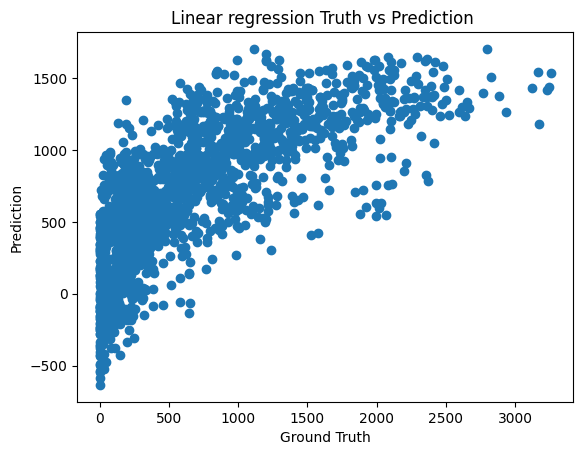

In [ ]:
plt.scatter(y_test, y_pred)
plt.title("Linear regression Truth vs Prediction ")
plt.xlabel("Ground Truth")
plt.ylabel("Prediction")
plt.show()

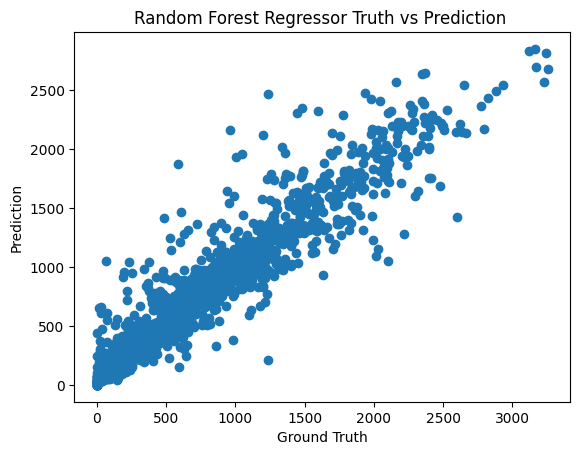

In [ ]:
plt.scatter(y_test, y_pred_rfr)
plt.title("Random Forest Regressor Truth vs Prediction ")
plt.xlabel("Ground Truth")
plt.ylabel("Prediction")
plt.show()

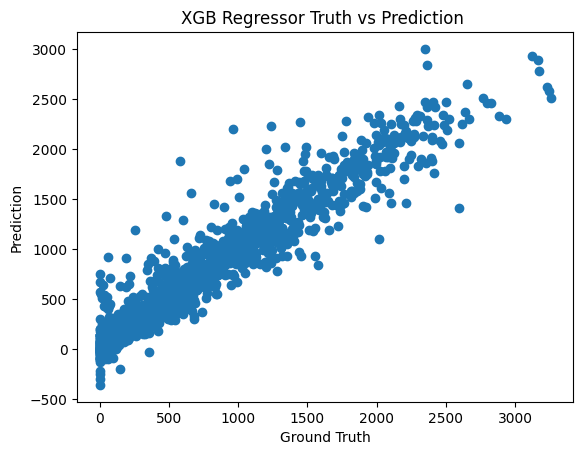

In [ ]:
plt.scatter(y_test, y_pred_xgbr)
plt.title("XGB Regressor Truth vs Prediction ")
plt.xlabel("Ground Truth")
plt.ylabel("Prediction")
plt.show()

## Hyper parameter Tuning for Random forest Regressor

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

# Number of trees in random forest
n_estimators = [int(x) for x in np.linspace(start=200,stop=2000,num=10)]

# Number of feature to consider at every split
max_features = ['auto','sqrt']

# maximun number of label allowed in each decision tree
max_depth = [int(x) for x in np.linspace(10, 120, num = 12)]

# minimum number of samples required to split a node
min_samples_split = [2, 5, 10]

# minimum number of samples required at each leaf node
min_samples_leaf = [1, 2, 4]

# Method of selecting samples for training each tree
bootstrap = [True, False]

# create the random grid
random_grid = {'n_estimators':n_estimators,
               'max_features':max_features,
               'max_depth':max_depth,
               'min_samples_split':min_samples_split,
               'min_samples_leaf':min_samples_leaf,
               'bootstrap':bootstrap}

In [ ]:
import time
start_time = time.time()

rf = RandomForestRegressor()
# Random search of parameters, using 3 fold cross validation
# search across 100 diffrent combinations, and use all avalible cores
rf_random = RandomizedSearchCV(estimator=rf, param_distributions=random_grid, n_iter= 100, cv= 3, verbose=2, random_state=42, n_jobs = -1)
# Fit the random search moodel
rf_random.fit(x_train, y_train)
y_pred_rf_random = rf_random.predict(x_test)

print("Time taken to training using randomize search :", time.time()-start_time)


Fitting 3 folds for each of 100 candidates, totalling 300 fits


/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_forest.py:413: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features=1.0` or remove this parameter as it is also the default value for RandomForestRegressors and ExtraTreesRegressors.
  warn(


Time taken to training using randomize search : 5376.702092885971


In [ ]:
get_metrics(y_test,y_pred_rf_random, "RandomForestRegressor Fine Tuning")

RandomForestRegressor Fine Tuning : ['MSE': 40024.653,'RMSE' :200.062,'MAE' : 119.887,'R2' : 1]


In [ ]:
rf_random.best_params_

{'n_estimators': 1400,
 'min_samples_split': 2,
 'min_samples_leaf': 1,
 'max_features': 'auto',
 'max_depth': 100,
 'bootstrap': True}

In [ ]:
rf_tuned = RandomForestRegressor(n_estimators = 1400,
                                 min_samples_split = 2,
                                 min_samples_leaf = 1,
                                 max_features="sqrt",
                                 max_depth= 100,
                                 bootstrap=False)

rf_tuned.fit(x_train,y_train)
y_pred_rf_tuned = rf_tuned.predict(x_test)

get_metrics(y_test, y_pred_rf_tuned, "RandomForestRegressor with Best Parameters")

## Hyperparameter Tuning for XGBoost Regressor

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error

import time
start_time = time.time()

params = {'max_depth': [3,5,6,10,15,20],
          'learning_rate':[0.01,0.1,0.2,0.3],
          'subsample':np.arange(0.5,1.0,0.1),
          'colsample_bytree':np.arange(0.4,1.0,0.1),
          'colsample_byleval':np.arange(0.4,1.0,0.1),
          'n_estimators':[100,500,1000]}

xgbr = XGBRegressor(seed=20)
rscv = RandomizedSearchCV(estimator=xgbr,
                          param_distributions=params,
                          scoring='neg_mean_squared_error',
                          n_iter=25,
                          cv=5,
                          verbose=1)

rscv.fit(x_train, y_train)

y_pred_xgb_random = rscv.predict(x_test)

get_metrics(y_test,y_pred_xgb_random, "XGBRegressor with Best Parameters")

print("Time taken to tarining using randomize search :",time.time()-start_time)

print("Best Parameters:", rscv.best_params_)

Fitting 5 folds for each of 25 candidates, totalling 125 fits


/usr/local/lib/python3.10/dist-packages/xgboost/core.py:160: UserWarning: [12:52:38] WARNING: /workspace/src/learner.cc:742: 
Parameters: { "colsample_byleval" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.10/dist-packages/xgboost/core.py:160: UserWarning: [12:52:38] WARNING: /workspace/src/learner.cc:742: 
Parameters: { "colsample_byleval" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.10/dist-packages/xgboost/core.py:160: UserWarning: [12:52:39] WARNING: /workspace/src/learner.cc:742: 
Parameters: { "colsample_byleval" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.10/dist-packages/xgboost/core.py:160: UserWarning: [12:52:40] WARNING: /workspace/src/learner.cc:742: 
Parameters: { "colsample_byleval" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.10/dist-packages/xgboost/core.py:160: UserWarning: [12:52:40] WARNING: /workspace/src/learner.cc:742: 
Parameters: { "colsample_b

XGBRegressor with Best Parameters : ['MSE': 33204.977,'RMSE' :182.222,'MAE' : 114.585,'R2' : 1]
Time taken to tarining using randomize search : 530.5301742553711
Best Parameters: {'subsample': 0.7999999999999999, 'n_estimators': 1000, 'max_depth': 6, 'learning_rate': 0.3, 'colsample_bytree': 0.7, 'colsample_byleval': 0.8999999999999999}


In [ ]:
xgbr = XGBRegressor(subsample = 0.7,
                    n_estimators = 1000,
                    max_depth = 6,
                    learning_rate = 0.3,
                    colsample_bytree=0.7,
                    colsample_byleval=0.8,
                    seed = 20)

xgbr.fit(x_train, y_train)

y_pred_tuned = xgbr.predict(x_test)

get_metrics(y_test,y_pred_tuned, "XGBRegressor with Best Parameters")

/usr/local/lib/python3.10/dist-packages/xgboost/core.py:160: UserWarning: [13:04:34] WARNING: /workspace/src/learner.cc:742: 
Parameters: { "colsample_byleval" } are not used.

  warnings.warn(smsg, UserWarning)


XGBRegressor with Best Parameters : ['MSE': 35586.47,'RMSE' :188.644,'MAE' : 118.792,'R2' : 1]


In [ ]:
xgbr = XGBRegressor(subsample = 0.7,
                    n_estimators = 1000,
                    max_depth = 6,
                    learning_rate = 0.07,
                    colsample_bytree=0.7,
                    colsample_byleval=0.8,
                    seed = 20)

xgbr.fit(x_train, y_train)

y_pred_tuned = xgbr.predict(x_test)

get_metrics(y_test,y_pred_tuned, "XGBRegressor with Best Parameters")

/usr/local/lib/python3.10/dist-packages/xgboost/core.py:160: UserWarning: [13:04:54] WARNING: /workspace/src/learner.cc:742: 
Parameters: { "colsample_byleval" } are not used.

  warnings.warn(smsg, UserWarning)


XGBRegressor with Best Parameters : ['MSE': 29300.625,'RMSE' :171.174,'MAE' : 104.209,'R2' : 1]


In [ ]:
x_test[0,:]

array([ 1.07807977,  0.22192612,  0.77468297,  1.82005277, -1.26200749,
       -0.25194272, -0.12916836, -0.17535463, -0.22754885, -5.47803337,
       -1.21546253,  1.00873202,  0.30459857,  1.74132735, -0.58152447,
       -0.57866842, -0.39840954, -0.40773843, -0.41815465, -0.40773843,
       -0.40559398, -0.41815465])

In [ ]:
y_test

3859       0
5647    1213
6735    1391
374      292
5791    1130
        ... 
1992     195
930      316
5634    2405
3291     164
6416     721
Name: Rented Bike Count, Length: 1752, dtype: int64

In [ ]:
x_test[1,:]

array([-0.65432992,  1.24504573,  0.23697162, -0.5001855 ,  0.56154562,
       -0.28664608, -0.12916836, -0.17535463, -0.22754885,  0.18254726,
        0.94712104,  0.14077827,  0.30459857, -0.57427456,  1.71961809,
       -0.57866842, -0.39840954, -0.40773843, -0.41815465, -0.40773843,
        2.4655198 , -0.41815465])

## Save ML Best Model

In [ ]:
import pickle
# open a file, where you want to store the data
file = open('xgboost_regressor_r2_1_v1.pkl', 'wb')

# dump information to that file
pickle.dump(xgbr, file)

In [ ]:
model_path = r"xgboost_regressor_r2_1_v1.pkl"
model = pickle.load(open(model_path, "rb"))

In [ ]:
data = [[ 1.07807977,  0.22192612,  0.77468297,  1.82005277, -1.26200749,
       -0.25194272, -0.12916836, -0.17535463, -0.22754885, -5.47803337,
       -1.21546253,  1.00873202,  0.30459857,  1.74132735, -0.58152447,
       -0.57866842, -0.39840954, -0.40773843, -0.41815465, -0.40773843,
       -0.40559398, -0.41815465],
        [-0.65432992,  1.24504573,  0.23697162, -0.5001855 ,  0.56154562,
       -0.28664608, -0.12916836, -0.17535463, -0.22754885,  0.18254726,
        0.94712104,  0.14077827,  0.30459857, -0.57427456,  1.71961809,
       -0.57866842, -0.39840954, -0.40773843, -0.41815465, -0.40773843,
        2.4655198 , -0.41815465]
      ]

prediction = model.predict(data)
list(prediction)

[253.05606, 1135.6803]

## Dump Scaling Parameters

In [ ]:
sc_dump_path = r"/content/sc.pkl"
pickle.dump(sc, open(sc_dump_path, "wb"))

## Load SC

In [ ]:
sc_dump_path = r"sc.pkl"
sc = pickle.load(open(sc_dump_path, "rb"))

In [ ]:
sc

StandardScaler()

## Users Input

In [ ]:
date = "25/03/2024"
hour = 14
temperature = 25
humidity = 91
wind_speed = 50
visibility = 70
solar_radiation = 3
rainfall = 30
snowfall = 0.0
seasons = "Spring"
holiday = "Holiday"
functioning_day = "No"

## Converting Data into Model Consumable Format

In [ ]:
from datetime import datetime

holiday_dic = {"No Holiday":0, "Holiday":1}
finctioning_day = {"No":0, "Yes":1}

def get_string_to_datetime(date):
    dt = datetime.strptime(date, "%d/%m/%Y")
    return {"day": dt.day, "month": dt.month, "year": dt.year, "week_day": dt.strftime("%A")}

str_to_date = get_string_to_datetime(date)
str_to_date

{'day': 25, 'month': 3, 'year': 2024, 'week_day': 'Monday'}

In [ ]:
df.columns

Index(['Rented Bike Count', 'Hour', 'Temperature(°C)', 'Humidity(%)',
       'Wind speed (m/s)', 'Visibility (10m)', 'Solar Radiation (MJ/m2)',
       'Rainfall(mm)', 'Snowfall (cm)', 'Holiday', 'Functioning Day', 'Day',
       'Month', 'Year', 'Spring', 'Summer', 'Winter', 'Monday', 'Saturday',
       'Sunday', 'Thursday', 'Tuesday', 'Wednesday'],
      dtype='object')

In [ ]:
u_input_list = [hour , temperature, humidity, wind_speed, visibility,
                solar_radiation, rainfall, snowfall, holiday_dic[holiday],
                finctioning_day[functioning_day], str_to_date["day"],
                str_to_date["month"], str_to_date["year"]]


features_name = ["Hour", 'Temperature(°C)', 'Humidity(%)',
       'Wind speed (m/s)', 'Visibility (10m)', 'Solar Radiation (MJ/m2)',
       'Rainfall(mm)', 'Snowfall (cm)', 'Holiday', 'Functioning Day', 'Day',
       'Month', 'Year',]

df_u_input = pd.DataFrame([u_input_list], columns=features_name)
df_u_input

,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Holiday,Functioning Day,Day,Month,Year
0,14,25,91,50,70,3,30,0.0,1,0,25,3,2024


In [ ]:
from datetime import datetime
import pandas as pd
import numpy  as np

In [ ]:
def season_to_df(seasons):
  seasons_cols = ['Spring', 'Summer', 'Winter']
  seasons_data = np.zeros((1, len(seasons_cols)), dtype="int")

  df_seasons = pd.DataFrame(seasons_data, columns=seasons_cols)
  if seasons in seasons_cols:
    df_seasons[seasons]=1
  return df_seasons

df_seasons = season_to_df(seasons)
df_seasons

,Spring,Summer,Winter
0,1,0,0


In [ ]:
def days_df(week_day):
  days_names = ['Monday', 'Saturday', 'Sunday', 'Thursday', 'Tuesday', 'Wednesday']
  days_name_data = np.zeros((1, len(days_names)), dtype="int")

  df_days = pd.DataFrame(days_name_data, columns = days_names)

  if week_day in days_names:
    df_days[week_day]=1
  return df_days

df_days = days_df(str_to_date["week_day"])
df_days

,Monday,Saturday,Sunday,Thursday,Tuesday,Wednesday
0,1,0,0,0,0,0


In [ ]:
['Hour', 'Temperature(°C)', 'Humidity(%)',
       'Wind speed (m/s)', 'Visibility (10m)', 'Solar Radiation (MJ/m2)',
       'Rainfall(mm)', 'Snowfall (cm)', 'Holiday', 'Functioning Day', 'Day',
       'Month', 'Year', 'Spring', 'Summer', 'Winter', 'Monday', 'Saturday',
       'Sunday', 'Thursday', 'Tuesday', 'Wednesday']

['Hour',
 'Temperature(°C)',
 'Humidity(%)',
 'Wind speed (m/s)',
 'Visibility (10m)',
 'Solar Radiation (MJ/m2)',
 'Rainfall(mm)',
 'Snowfall (cm)',
 'Holiday',
 'Functioning Day',
 'Day',
 'Month',
 'Year',
 'Spring',
 'Summer',
 'Winter',
 'Monday',
 'Saturday',
 'Sunday',
 'Thursday',
 'Tuesday',
 'Wednesday']

In [ ]:
df_for_pred = pd.concat([df_u_input,df_seasons, df_days], axis=1)
df_for_pred

,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Holiday,Functioning Day,...,Year,Spring,Summer,Winter,Monday,Saturday,Sunday,Thursday,Tuesday,Wednesday
0,14,25,91,50,70,3,30,0.0,1,0,...,2024,1,0,0,1,0,0,0,0,0


In [ ]:
sc_data_for_pred = sc.transform(df_for_pred)
sc_data_for_pred

array([[ 0.3562424 ,  1.01214045,  1.60569143, 46.67799252, -2.25952072,
         2.81352104, 25.27434606, -0.17535463,  4.39466079, -5.47803337,
         1.06094123, -1.01649341, 21.8302469 ,  1.74132735, -0.58152447,
        -0.57866842,  2.50998008, -0.40773843, -0.41815465, -0.40773843,
        -0.40559398, -0.41815465]])

## Prediction in Deployment

In [ ]:
print(f"Ranted Bike Demand on date: {date}, and Time: {hour} is : {round(model.predict(sc_data_for_pred).tolist()[0])}")

Ranted Bike Demand on date: 25/03/2024, and Time: 14 is : -75
